# Stage 6: Validation and calibration of the main PD model

Input: the committed result tables `artifacts/validation_*.csv` (written by
`python -m src.holdout`) and the `pd_scores` table in the DuckDB database (stored PDs of the
frozen Stage 5 model). This notebook **never rescores** the hold-out and writes no
artifacts: it only reads stored scores, so running it is not another look at the hold-out.
It opens the database read-only.

Context (see `docs/decision_log.md`):
- **Scope (D-026):** the model covers loans outside `credit_type = EQUI`. EQUI loans
  (99.99% default, D-017) are counted but not scored.
- **Two looks at the hold-out (D-025):** a first look found that the model, then fitted on
  all loans, over-predicted every non-EQUI loan. After the D-026 refit the hold-out was
  evaluated a second time, so the figures below are **not fully unbiased**.
- This is **out-of-sample, not out-of-time** validation (D-004).
- The pass/fail thresholds are **heuristics** for this project, fixed before the first
  look, not regulatory standards.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve

from src import config, validation


def artifact(name: str) -> pd.DataFrame:
    return pd.read_csv(config.ARTIFACTS_DIR / f"{config.VALIDATION_ARTIFACT_PREFIX}{name}.csv")


con = duckdb.connect(str(config.DUCKDB_PATH), read_only=True)
scores = con.execute(
    f"SELECT s.ID, s.sample, s.pd, l.{config.TARGET_COL} "
    f"FROM {config.PD_SCORES_TABLE} AS s JOIN {config.LOANS_TABLE} AS l USING ({config.ID_COL}) "
    f"ORDER BY s.{config.ID_COL}"
).df()
con.close()
holdout = scores[scores["sample"] == config.SAMPLE_HOLDOUT]
y, p = holdout[config.TARGET_COL], holdout["pd"]

plt.rcParams.update({
    "axes.edgecolor": config.COLOR_INK_MUTED, "axes.labelcolor": config.COLOR_INK,
    "xtick.color": config.COLOR_INK_MUTED, "ytick.color": config.COLOR_INK_MUTED,
    "axes.grid": True, "grid.color": config.COLOR_GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": config.COLOR_SURFACE, "axes.facecolor": config.COLOR_SURFACE,
})
print(f"hold-out loans scored: {len(holdout):,}")

hold-out loans scored: 39,981


## 1. Scope (D-026)

In [2]:
scope = artifact("scope")
print(scope.to_string(index=False))

n = scope.set_index(["sample", "scope"])["n_loans"]
assert n[(config.SAMPLE_HOLDOUT, "in_scope")] == 39_981
assert n[(config.SAMPLE_HOLDOUT, "out_of_scope_EQUI")] == 4_620
assert n[(config.SAMPLE_DEVELOPMENT, "in_scope")] == 93_391
assert n[(config.SAMPLE_DEVELOPMENT, "out_of_scope_EQUI")] == 10_678
assert n.sum() == config.EXPECTED_N_ROWS
assert len(holdout) == 39_981  # pd_scores holds in-scope loans only

     sample             scope  n_loans  n_defaults  observed_rate
development          in_scope    93391     14970.0       0.160294
development out_of_scope_EQUI    10678     10677.0       0.999906
    holdout          in_scope    39981      6372.0       0.159376
    holdout out_of_scope_EQUI     4620      4620.0       1.000000


**Reading:** 39,981 hold-out loans are in scope and scored. The 4,620 hold-out EQUI loans
all defaulted; the model says nothing about them (D-026 limitation).

## 2. Discrimination

AUC, Gini, KS and Brier score on the in-scope hold-out, with 95% bootstrap intervals
(1,000 resamples, seed 42), next to the cross-validation mean and the in-sample fit.

In [3]:
metrics = artifact("metrics").set_index("population")
intervals = artifact("confidence_intervals").set_index("metric")
print(metrics.round(4).to_string())
print()
print(intervals.round(4).to_string())

# cross-check: recomputing from the stored scores reproduces the artifact
recomputed = validation.discrimination_metrics(y, p)
for name, value in recomputed.items():
    assert abs(value - metrics.loc["holdout_in_scope", name]) < 1e-6, name

assert round(metrics.loc["holdout_in_scope", "auc"], 3) == 0.670
assert round(metrics.loc["cv_mean_development", "auc"], 3) == 0.675
assert round(intervals.loc["auc", "ci_lower"], 3) == 0.662
assert round(intervals.loc["auc", "ci_upper"], 3) == 0.678

                       n_loans     auc    gini      ks   brier
population                                                    
development_in_sample  93391.0  0.6749  0.3498  0.2718  0.1230
holdout_in_scope       39981.0  0.6703  0.3405  0.2667  0.1222
cv_mean_development        NaN  0.6746  0.3492  0.2732  0.1230

        estimate  ci_lower  ci_upper        population
metric                                                
auc       0.6703    0.6620    0.6784  holdout_in_scope
gini      0.3405    0.3240    0.3569  holdout_in_scope
ks        0.2667    0.2558    0.2813  holdout_in_scope
brier     0.1222    0.1200    0.1245  holdout_in_scope


**Reading:** hold-out AUC 0.670 (95% interval 0.662 to 0.678), against a CV mean of 0.675.
The drop of 0.004 is well within the green limit of 0.02, so there is no sign of
overfitting. The ranking power is modest (Gini 0.34), as expected for a model without LTV
or debt-to-income (D-017).

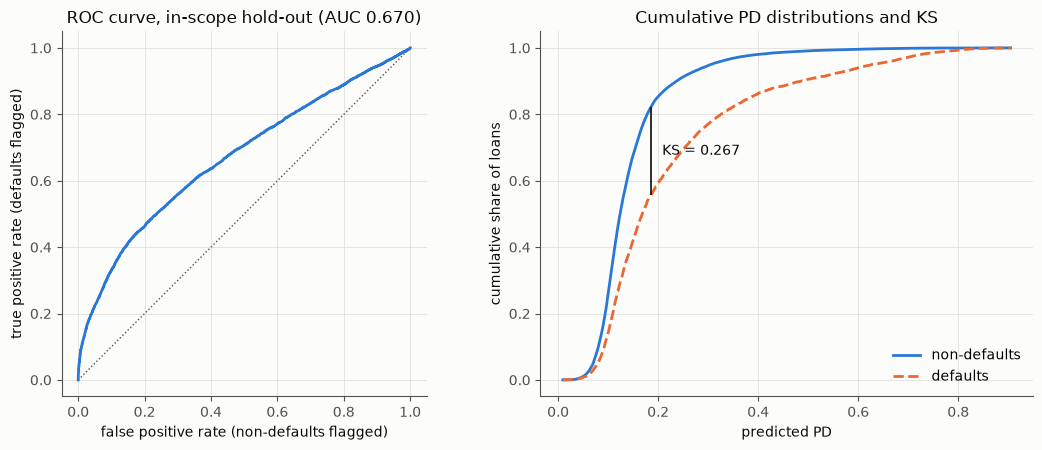

In [4]:
fpr, tpr, _ = roc_curve(y, p)
auc = metrics.loc["holdout_in_scope", "auc"]

grid = np.sort(p.unique())
cdf_default = np.searchsorted(np.sort(p[y == 1]), grid, side="right") / (y == 1).sum()
cdf_good = np.searchsorted(np.sort(p[y == 0]), grid, side="right") / (y == 0).sum()
gap = cdf_good - cdf_default
k = int(np.argmax(gap))
assert abs(gap[k] - metrics.loc["holdout_in_scope", "ks"]) < 1e-3  # same KS as the artifact

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6))
ax1.plot([0, 1], [0, 1], color=config.COLOR_INK_MUTED, linewidth=1, linestyle=":")
ax1.plot(fpr, tpr, color=config.COLOR_PRIMARY, linewidth=2)
ax1.set_xlabel("false positive rate (non-defaults flagged)")
ax1.set_ylabel("true positive rate (defaults flagged)")
ax1.set_title(f"ROC curve, in-scope hold-out (AUC {auc:.3f})", color=config.COLOR_INK)
ax1.set_aspect("equal")

ax2.plot(grid, cdf_good, color=config.COLOR_PRIMARY, linewidth=2, label="non-defaults")
ax2.plot(grid, cdf_default, color=config.COLOR_SECONDARY, linewidth=2, linestyle="--", label="defaults")
ax2.vlines(grid[k], cdf_default[k], cdf_good[k], color=config.COLOR_INK, linewidth=1.2)
ax2.annotate(f"KS = {gap[k]:.3f}", (grid[k], (cdf_good[k] + cdf_default[k]) / 2),
             xytext=(8, 0), textcoords="offset points", va="center", color=config.COLOR_INK)
ax2.set_xlabel("predicted PD")
ax2.set_ylabel("cumulative share of loans")
ax2.set_title("Cumulative PD distributions and KS", color=config.COLOR_INK)
ax2.legend(frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "09_roc_ks.png", dpi=config.FIGURE_DPI)
plt.show()

## 3. Calibration and the pre-set criteria (D-025)

Calibration-in-the-large (binomial test of observed defaults against mean PD), calibration
intercept and slope, and Hosmer-Lemeshow. Hosmer-Lemeshow is shown **without a verdict**:
with about 40,000 loans it rejects even trivial misfit.

In [5]:
calibration = artifact("calibration").set_index("population")
criteria = artifact("criteria")
print(calibration.round(4).to_string())
print()
print(criteria.round(4).to_string(index=False))

hold = calibration.loc["holdout_in_scope"]
assert round(hold["mean_pd"], 4) == 0.1597 and round(hold["observed_rate"], 4) == 0.1594
assert round(hold["binomial_p"], 2) == 0.86
assert round(hold["calibration_slope"], 3) == 1.008
status = criteria.set_index("criterion")["status"]
assert (status == "green").sum() == 3 and status["max_decile_gap"] == "amber"

                       n_loans  mean_pd  observed_rate  binomial_p  calibration_intercept  calibration_slope  hl_statistic  hl_df  hl_p_value
population                                                                                                                                   
development_in_sample    93391   0.1603         0.1603      0.9715                 0.0003             0.9996      219.8888      8         0.0
holdout_in_scope         39981   0.1597         0.1594      0.8645                -0.0026             1.0077       87.5184      8         0.0

                criterion  value status
auc_drop_cv_minus_holdout 0.0043  green
               binomial_p 0.8645  green
        calibration_slope 1.0077  green
           max_decile_gap 0.0248  amber


In [6]:
deciles = artifact("calibration_deciles")
print(deciles.round(4).to_string(index=False))

# cross-check: the SQL NTILE table equals a pandas recomputation from pd_scores
# (same order: PD, then ID; NTILE and array_split both put the extra rows in the first bins)
ordered = holdout.sort_values(["pd", config.ID_COL])
chunks = np.array_split(np.arange(len(ordered)), config.CALIBRATION_N_BINS)
bins = np.concatenate([np.full(len(c), i + 1) for i, c in enumerate(chunks)])
check = ordered.assign(bin=bins).groupby("bin").agg(
    n_loans=("pd", "size"), mean_pd=("pd", "mean"), observed_rate=(config.TARGET_COL, "mean"))
assert (check["n_loans"].to_numpy() == deciles["n_loans"].to_numpy()).all()
assert np.allclose(check["mean_pd"], deciles["mean_pd"], atol=1e-6)
assert np.allclose(check["observed_rate"], deciles["observed_rate"], atol=1e-6)

first = deciles.set_index("bin").loc[1]
assert round(first["gap"], 3) == 0.025  # the amber criterion: decile 1
assert deciles["gap"].abs().idxmax() == 0

 bin  n_loans  n_defaults  pd_min  pd_max  mean_pd  observed_rate     gap
   1     3999       369.0  0.0094  0.0817   0.0675         0.0923  0.0248
   2     3998       396.0  0.0817  0.0958   0.0893         0.0990  0.0097
   3     3998       380.0  0.0958  0.1061   0.1010         0.0950 -0.0059
   4     3998       420.0  0.1061  0.1160   0.1110         0.1051 -0.0060
   5     3998       436.0  0.1160  0.1282   0.1219         0.1091 -0.0128
   6     3998       478.0  0.1282  0.1434   0.1355         0.1196 -0.0160
   7     3998       579.0  0.1434  0.1630   0.1528         0.1448 -0.0080
   8     3998       626.0  0.1630  0.1936   0.1766         0.1566 -0.0200
   9     3998      1004.0  0.1937  0.2747   0.2283         0.2511  0.0228
  10     3998      1684.0  0.2747  0.9045   0.4131         0.4212  0.0081


**Reading:** over the in-scope hold-out, mean PD is 15.97% against an observed 15.94%
(binomial p = 0.86), and the calibration slope is 1.008. Three of the four pre-set criteria
are green. The amber one is the largest PD-decile gap: in the lowest-risk decile the model
predicts 6.8% and 9.2% default, a 2.5 pp under-prediction (green limit 2 pp, amber 5 pp).
Its lowest PDs are slightly too optimistic.

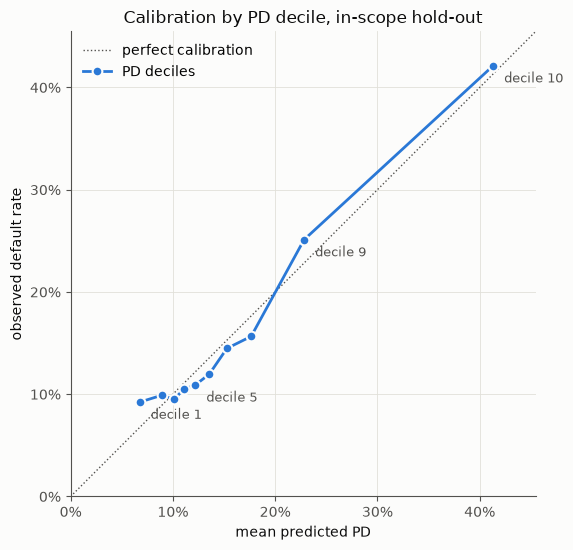

In [7]:
fig, ax = plt.subplots(figsize=(6, 5.6))
top = max(deciles["mean_pd"].max(), deciles["observed_rate"].max()) * 1.08
ax.plot([0, top], [0, top], color=config.COLOR_INK_MUTED, linewidth=1, linestyle=":",
        label="perfect calibration")
ax.plot(deciles["mean_pd"], deciles["observed_rate"], color=config.COLOR_PRIMARY, linewidth=2,
        marker="o", markersize=7, markeredgecolor=config.COLOR_SURFACE, markeredgewidth=1.5,
        label="PD deciles")
for _, row in deciles.iterrows():
    if row["bin"] in (1, 5, 9, 10):
        ax.annotate(f"decile {int(row['bin'])}", (row["mean_pd"], row["observed_rate"]),
                    xytext=(8, -12), textcoords="offset points", color=config.COLOR_INK_MUTED, fontsize=9)
ax.set_xlim(0, top)
ax.set_ylim(0, top)
ax.set_aspect("equal")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("mean predicted PD")
ax.set_ylabel("observed default rate")
ax.set_title("Calibration by PD decile, in-scope hold-out", color=config.COLOR_INK)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "10_calibration_deciles.png", dpi=config.FIGURE_DPI)
plt.show()

## 4. Calibration by `loan_amount` and `income_clean` decile (D-023)

D-023 asked whether the known top-5% upticks of these two features show up as a misfit.

In [8]:
feature_deciles = artifact("feature_deciles")
print(feature_deciles.round(4).to_string(index=False))

top_gap = feature_deciles[feature_deciles["bin"] == config.CALIBRATION_N_BINS].set_index("variable")["gap"]
assert round(top_gap["loan_amount"], 3) == 0.034
assert round(top_gap["income_clean"], 3) == 0.035
assert feature_deciles["gap"].abs().max() < config.CRITERION_DECILE_GAP[1]  # inside the amber limit
assert feature_deciles.loc[feature_deciles["bin"] < config.CALIBRATION_N_BINS, "gap"].abs().max() < 0.022

    variable  bin  bin_min   bin_max  n_loans  mean_pd  observed_rate     gap
income_clean    1    120.0    2640.0     3726   0.2746         0.2920  0.0174
income_clean    2   2640.0    3420.0     3726   0.2119         0.2026 -0.0093
income_clean    3   3420.0    4200.0     3726   0.1901         0.1812 -0.0089
income_clean    4   4200.0    4980.0     3726   0.1721         0.1677 -0.0044
income_clean    5   4980.0    5760.0     3726   0.1593         0.1444 -0.0150
income_clean    6   5760.0    6720.0     3725   0.1476         0.1364 -0.0112
income_clean    7   6720.0    7860.0     3725   0.1335         0.1211 -0.0124
income_clean    8   7860.0    9360.0     3725   0.1224         0.1152 -0.0072
income_clean    9   9360.0   12180.0     3725   0.1100         0.1208  0.0108
income_clean   10  12180.0  374400.0     3725   0.0853         0.1205  0.0352
 loan_amount    1  26500.0  126500.0     3999   0.2214         0.2421  0.0206
 loan_amount    2 126500.0  176500.0     3998   0.1875         0

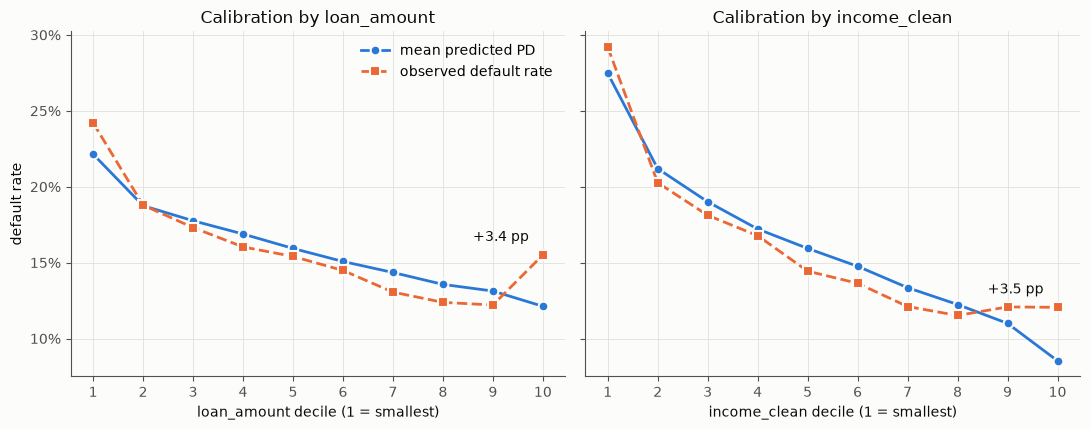

In [9]:
labels = {"loan_amount": "loan_amount decile", config.INCOME_CLEAN_COL: "income_clean decile"}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
for ax, (variable, label) in zip(axes, labels.items()):
    t = feature_deciles[feature_deciles["variable"] == variable]
    ax.plot(t["bin"], t["mean_pd"], color=config.COLOR_PRIMARY, linewidth=2, marker="o", markersize=7,
            markeredgecolor=config.COLOR_SURFACE, markeredgewidth=1.5, label="mean predicted PD")
    ax.plot(t["bin"], t["observed_rate"], color=config.COLOR_SECONDARY, linewidth=2, linestyle="--",
            marker="s", markersize=7, markeredgecolor=config.COLOR_SURFACE, markeredgewidth=1.5,
            label="observed default rate")
    last = t[t["bin"] == config.CALIBRATION_N_BINS].iloc[0]
    ax.annotate(f"{last['gap'] * 100:+.1f} pp", (last["bin"], last["observed_rate"]),
                xytext=(-10, 10), textcoords="offset points", ha="right", color=config.COLOR_INK)
    ax.set_xticks(range(1, config.CALIBRATION_N_BINS + 1))
    ax.set_xlabel(f"{label} (1 = smallest)")
    ax.set_title(f"Calibration by {variable}", color=config.COLOR_INK)
axes[0].set_ylabel("default rate")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[0].legend(frameon=False, loc="upper right")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "11_calibration_by_feature.png", dpi=config.FIGURE_DPI)
plt.show()

**Reading:** deciles 1 to 9 of both features are within about 2 pp, but the top decile
is under-predicted: by 3.4 pp for `loan_amount` (PD 12.1%, observed 15.5%) and by 3.5 pp for
`income_clean` (PD 8.5%, observed 12.1%). This is the uptick seen in Stage 5, which a single
log-linear term cannot follow. It stays inside the 5 pp amber limit and the `loan_amount`
coefficient keeps its sign, so the D-023 revisit trigger **did not fire**. The misfit is
**accepted as a documented limitation** (decided by Bruno, 2026-10-01).

## 5. Segments

In [10]:
segments = artifact("segments")
print(segments.round(4).to_string(index=False))

p2 = segments.set_index(["variable", "level"]).loc[("loan_purpose", "p2")]
assert p2["n_loans"] == 857 and round(p2["gap"], 3) == 0.043
others = segments[~((segments["variable"] == "loan_purpose") & (segments["level"] == "p2"))]
assert others["gap"].abs().max() < 0.01
assert segments["auc"].between(0.63, 0.69).all()

    variable level  n_loans  mean_pd  observed_rate     gap    auc
loan_purpose    p1     9051   0.1475         0.1433 -0.0042 0.6628
loan_purpose    p2      857   0.2358         0.2789  0.0431 0.6889
loan_purpose    p3    15231   0.1773         0.1753 -0.0020 0.6608
loan_purpose    p4    14807   0.1447         0.1460  0.0014 0.6698
   loan_type type1    30593   0.1449         0.1420 -0.0029 0.6496
   loan_type type2     5500   0.2516         0.2602  0.0086 0.6647
   loan_type type3     3888   0.1463         0.1533  0.0070 0.6370


**Reading:** AUC is 0.64 to 0.69 in every `loan_type` and `loan_purpose` level, and every
level is calibrated within 1 pp, except `loan_purpose = p2`: a small segment (857 loans)
under-predicted by 4.3 pp, inside the amber limit.

## 6. Coefficient stability (diagnostic refit)

The same features are refitted on the hold-out, using the development-fitted preprocessing so
the scales match. This refit is **diagnostic only**: it is never used for scoring.

In [11]:
stability = artifact("coefficient_stability")
print(stability.round(4).to_string(index=False))

s = stability.set_index("feature")
assert s["same_sign"].sum() == 9
assert not s.loc["loan_purpose_p4", "same_sign"]
assert s.loc["loan_purpose_p4", "holdout_p_value"] > 0.05  # not significant either way
assert not s.loc[config.INCOME_CLEAN_COL, "ci_overlap"]
assert s.loc["loan_amount", "holdout_coefficient"] > 0 and s.loc["loan_amount", "holdout_p_value"] < 0.001

                  feature  holdout_coefficient  holdout_std_error  holdout_p_value  dev_coefficient  dev_std_error  same_sign  ci_overlap
             income_clean              -0.3501             0.0195           0.0000          -0.4153         0.0127       True       False
     income_clean_missing              -0.3330             0.0707           0.0000          -0.2153         0.0460       True        True
              loan_amount               0.0997             0.0192           0.0000           0.1164         0.0124       True        True
    lump_sum_payment_lpsm               2.7100             0.0864           0.0000           2.4867         0.0557       True        True
Neg_ammortization_neg_amm               1.1400             0.0398           0.0000           1.1721         0.0255       True        True
          loan_type_type2               0.7292             0.0396           0.0000           0.6040         0.0261       True        True
          loan_type_type3         

**Reading:** 9 of 10 terms keep their sign. The exception, `loan_purpose_p4`, is close to zero
and not significant in either sample. `loan_amount` stays positive and significant (+0.100),
so the D-023 sign reasoning holds. `income_clean` keeps its direction but is weaker on the
hold-out (-0.350 against -0.415), and the two 95% intervals do not overlap. The income
effect may be somewhat overstated in development; this is noted, not acted on.

## 7. Conclusion

- **Discrimination is stable:** hold-out AUC 0.670 against a CV mean of 0.675.
- **Calibration is good overall:** mean PD 15.97% against an observed 15.94%, slope 1.008.
  Of the four pre-set criteria, three are green. The fourth is amber: the lowest PD decile
  is under-predicted by 2.5 pp.
- **Documented limitations:**
  - the top `loan_amount` and `income_clean` deciles are under-predicted by about 3.5 pp
    (D-023, accepted);
  - `loan_purpose = p2` is under-predicted by 4.3 pp;
  - the income coefficient is weaker on the hold-out;
  - the model covers only loans outside EQUI (D-026);
  - the hold-out was looked at twice (D-025);
  - the model lacks LTV and debt-to-income (D-017).
- The stored PDs (`pd_scores`) are the input for the Stage 7 illustrative risk grades.